## Project OverView
This notebook explores the key factors influencing student academic performance through a structured, multi-hypothesis data analysis approach. Using a dataset of student attributes—including study habits, attendance, and lifestyle factors—we investigate which variables most strongly predict exam success.

## Hypotheses:
#### **H1: Individual Impact**
- Hours studied explains more variance in exam scores than attendance rate or sleep hours when analyzed separately.
Analytical Approach = Simple linear Regression

#### **H2: 2: Combined Effects**
- The combination of hours studied AND attendance rate predicts exam scores better than either variable alone.
Analyticial Approach = Multiple regression with interaction.

#### **H3: Threshold Success**
- Students who study more than 20 hours per week AND get more than 7 hours of sleep score significantly higher than those meeting only one or neither threshold.
Analytical Approach = ANOVA/ Group Comparison.

#### **H4: Variable Comparison**
- Hours studied has the strongest correlation with exam scores among all continuous variables in the dataset.
Analytical Approach = Correlation Matrix Analysis.

#### Analysis Workflow
1. Data Cleaning & Preprocessing
   
2. Exploratory Data Analysis (EDA)
   
3. Hypothesis 1: Simple Linear Regressions
   
4. Hypothesis 2: Multiple Regression with Interaction
   
5. Hypothesis 3: Threshold/Categorical Analysis
   
6. Hypothesis 4: Full Correlation Analysis
   
7. Conclusions & Key Findings

#### Importing Libraries
- This will help set out my libraries, Data visulaistion and style formatting.


In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Setting visualisation styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Displaying settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


### Loading Data

In [6]:
# Loading the dataset
df = pd.read_csv('../Data/Raw/StudentPerformanceFactors.csv')

# Quick check to see the shape and first few rows of the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (6607, 20)

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Cleaning the data and Preparing Data

In [7]:
# comprehensive info including data types and non-null counts
print("=== DATASET INFO ===")
print(df.info())
print("\n" + "="*50)

# Checking for missing values
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Values'] > 0])

# Summary of  statistics
print("\n=== SUMMARY STATISTICS ===")
df.describe()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence             

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


### Handling missing Values

In [8]:
# Dropping rows with missing values 
print(f"Rows before dropping: {len(df)}")
df_clean = df.dropna()
print(f"Rows after dropping: {len(df_clean)}")

# Verifying no missing values remain
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

Rows before dropping: 6607
Rows after dropping: 6378

Missing values after cleaning:
0


### Check and Handle Outliers

Numerical columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


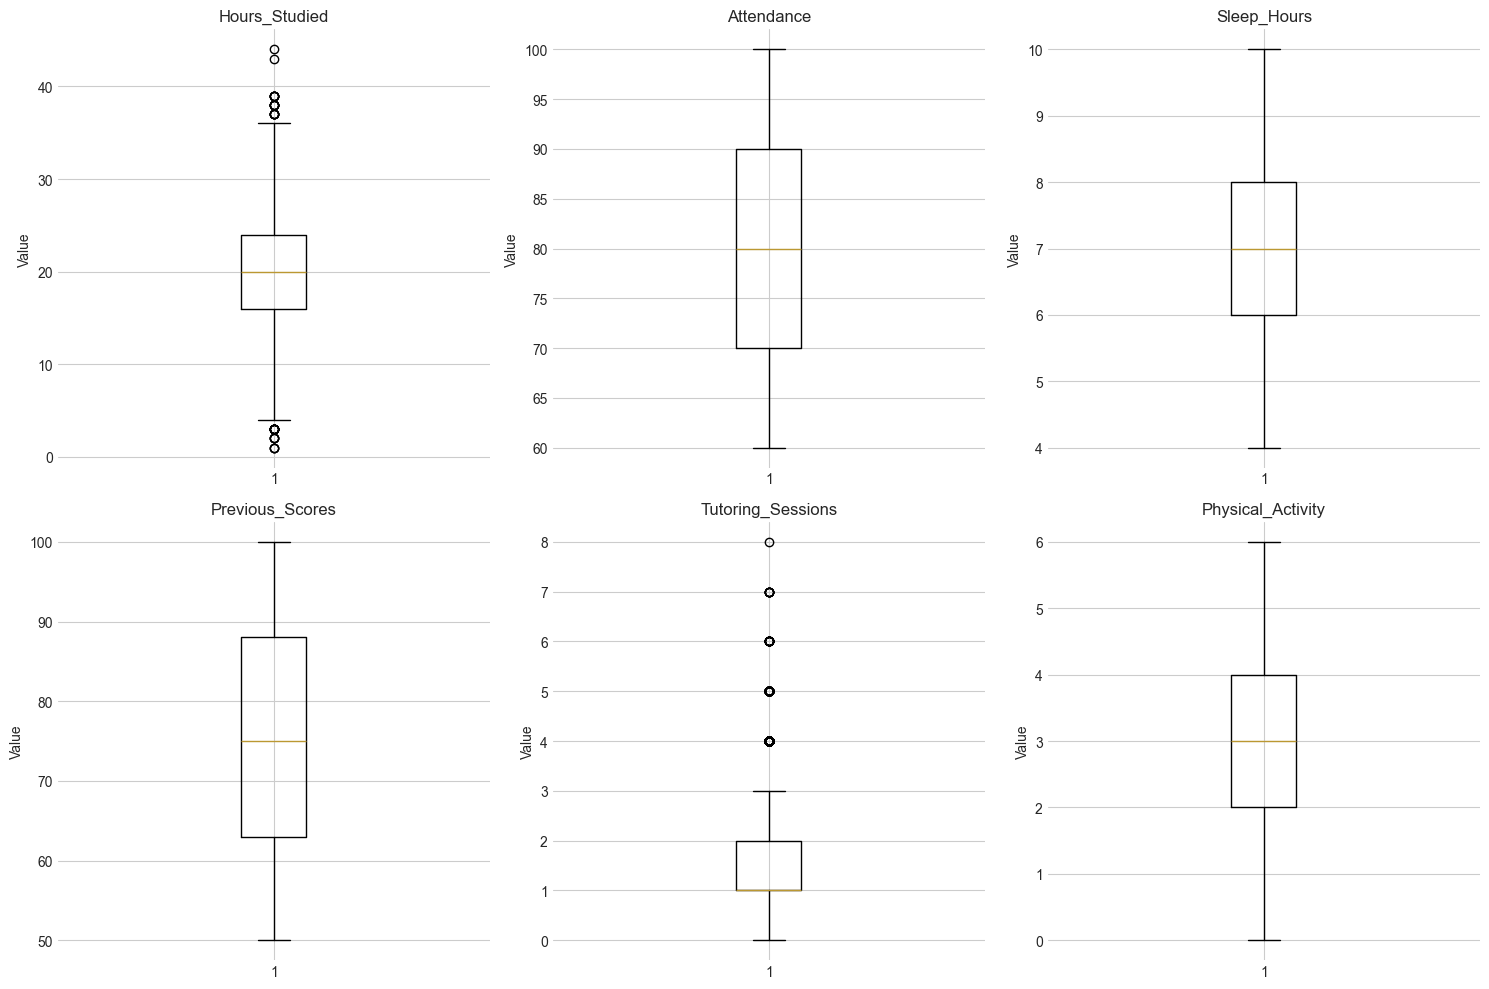


=== OUTLIER DETECTION ===
Hours_Studied: 40 outliers detected
Attendance: 0 outliers detected
Sleep_Hours: 0 outliers detected
Previous_Scores: 0 outliers detected
Tutoring_Sessions: 423 outliers detected
Physical_Activity: 0 outliers detected
Exam_Score: 103 outliers detected


In [9]:
# Identifying numerical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Creating boxplots to visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:6]):  # Limitting to first 6 columns
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Using IQR method to detect outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\n=== OUTLIER DETECTION ===")
for col in numerical_cols:
    count, lower, upper = detect_outliers_iqr(df_clean, col)
    print(f"{col}: {count} outliers detected")

### Check Data Types and Fix Issues

In [10]:
# Checking the current data types
print("=== DATA TYPES BEFORE ===")
print(df_clean.dtypes)

# Converting categorical columns if needed
categorical_columns = ['Extracurricular Activities', 'Gender', 'Parental Involvement']  # Adjust based on actual columns

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        print(f"Converted {col} to category")

# Verifying changes
print("\n=== DATA TYPES AFTER ===")
print(df_clean.dtypes)

=== DATA TYPES BEFORE ===
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object
Converted Gender to category

=== DATA TYPES AFTER ===
Hours_Studied                    int64
Attendance                       int64
Parental_Involvement            object
Access_to_Resources             object
Extracurr

C:\Users\symem\AppData\Local\Temp\ipykernel_18816\3907693573.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].astype('category')


#### Fixing the warning

In [12]:
# Safer way to convert data types (fixes the warning)
print("=== DATA TYPES BEFORE ===")
print(df_clean.dtypes)

# Creating a proper copy first to avoid the warning
df_clean = df_clean.copy()

# Converting categorical columns
categorical_columns = ['Gender', 'Parental_Involvement', 'Extracurricular_Activities', 
                       'Learning_Disabilities', 'School_Type']  # Adjust based on my actual columns

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        print(f"Converted {col} to category")

# Verify changes
print("\n=== DATA TYPES AFTER ===")
print(df_clean.dtypes)

=== DATA TYPES BEFORE ===
Hours_Studied                    int64
Attendance                       int64
Parental_Involvement            object
Access_to_Resources             object
Extracurricular_Activities      object
Sleep_Hours                      int64
Previous_Scores                  int64
Motivation_Level                object
Internet_Access                 object
Tutoring_Sessions                int64
Family_Income                   object
Teacher_Quality                 object
School_Type                     object
Peer_Influence                  object
Physical_Activity                int64
Learning_Disabilities           object
Parental_Education_Level        object
Distance_from_Home              object
Gender                        category
Exam_Score                       int64
Study_Sleep_Group               object
dtype: object
Converted Gender to category
Converted Parental_Involvement to category
Converted Extracurricular_Activities to category
Converted Learning_D

### Machine Learning for H3

In [13]:
# Creating threshold groups for Hypothesis 3
# Assuming columns: 'Hours_Studied', 'Sleep_Hours', 'Exam_Score'
# Adjusting column names based on your actual dataset

# First, I'll check actual column names
print("Available columns:")
print(df_clean.columns.tolist())

# Then, I'll Create threshold groups
def create_study_sleep_group(row):
    high_study = row['Hours_Studied'] > 20  # Adjusting threshold based on my data distribution
    high_sleep = row['Sleep_Hours'] > 7      # Adjusting threshold
    
    if high_study and high_sleep:
        return 'High Both'
    elif high_study and not high_sleep:
        return 'High Study Only'
    elif not high_study and high_sleep:
        return 'High Sleep Only'
    else:
        return 'Low Both'

df_clean['Study_Sleep_Group'] = df_clean.apply(create_study_sleep_group, axis=1)

# Checking through group distribution
print("\n=== GROUP DISTRIBUTION ===")
print(df_clean['Study_Sleep_Group'].value_counts())
print(f"\nPercentage:")
print(df_clean['Study_Sleep_Group'].value_counts(normalize=True) * 100)

Available columns:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Study_Sleep_Group']

=== GROUP DISTRIBUTION ===
Study_Sleep_Group
Low Both           2130
High Study Only    1838
High Sleep Only    1294
High Both          1116
Name: count, dtype: int64

Percentage:
Study_Sleep_Group
Low Both          33.40
High Study Only   28.82
High Sleep Only   20.29
High Both         17.50
Name: proportion, dtype: float64


### Save Clean Data

In [15]:
# Saving cleaned dataset for future usage
df_clean.to_csv('../Data/Cleaned/cleaned_student_data.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


### Exploratory Data Analysis (EDA)
- Distribution of Key Variables. 

Creating a subplot showcasing Exam scores


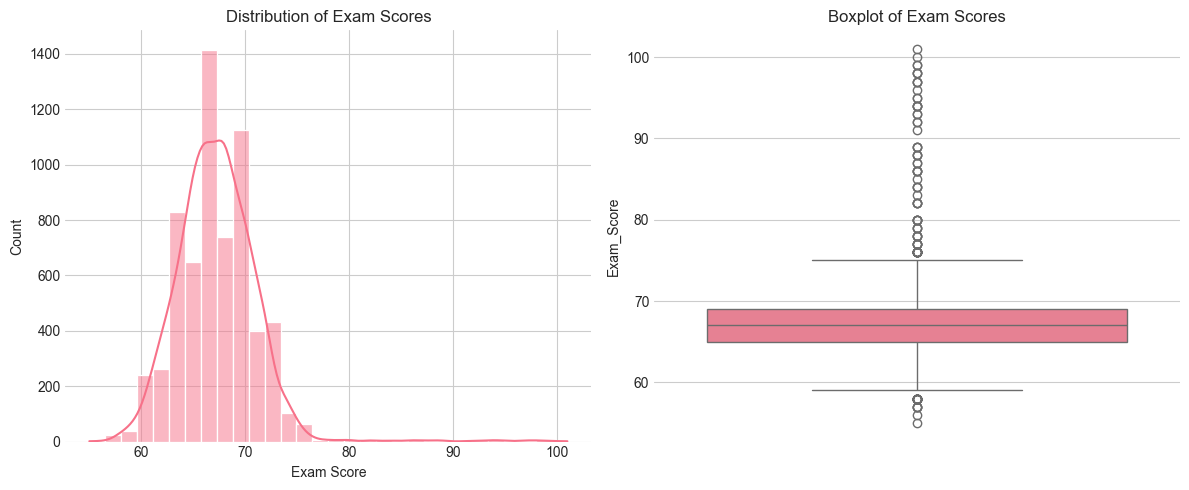

=== EXAM SCORE STATISTICS ===
count   6378.00
mean      67.25
std        3.91
min       55.00
25%       65.00
50%       67.00
75%       69.00
max      101.00
Name: Exam_Score, dtype: float64


In [16]:
# Distribution of target variable (Exam Score)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Exam_Score'], kde=True, bins=30)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Exam_Score'])
plt.title('Boxplot of Exam Scores')

plt.tight_layout()
plt.show()

# Summary statistics for exam score
print("=== EXAM SCORE STATISTICS ===")
print(df_clean['Exam_Score'].describe())

### Showing the relationship with Exam score

Using a scatter plot to show variables that are continuous

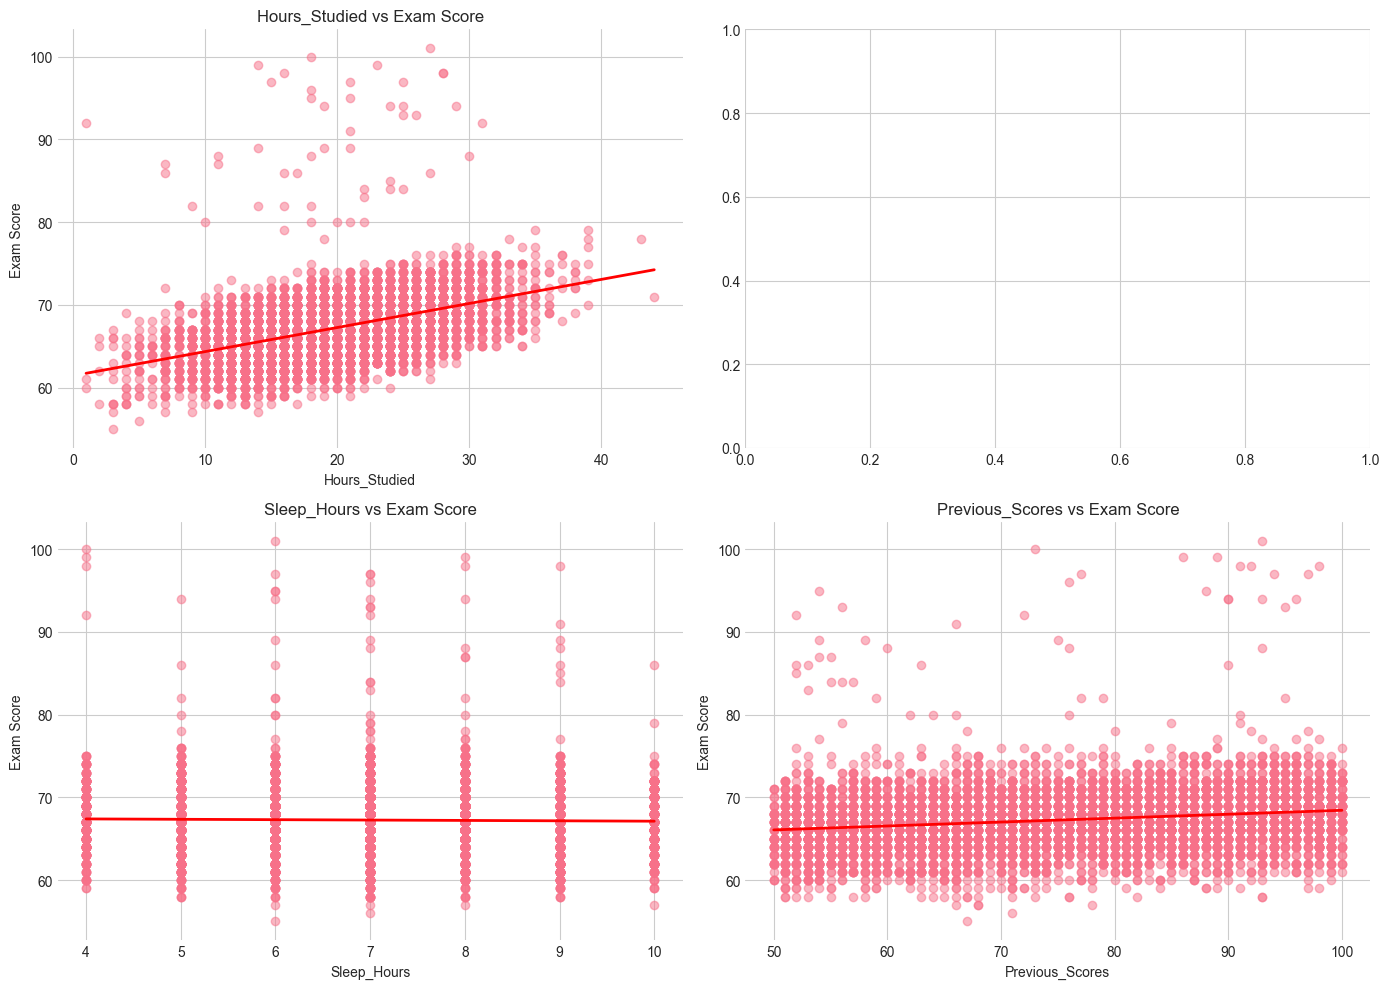

In [17]:
# Scatter plots for continuous variables
continuous_vars = ['Hours_Studied', 'Attendance_Rate', 'Sleep_Hours', 'Previous_Scores']  # Adjust as needed

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, var in enumerate(continuous_vars):
    if var in df_clean.columns:
        axes[i].scatter(df_clean[var], df_clean['Exam_Score'], alpha=0.5)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Exam Score')
        axes[i].set_title(f'{var} vs Exam Score')
        
        # Adding trend line
        z = np.polyfit(df_clean[var], df_clean['Exam_Score'], 1)
        p = np.poly1d(z)
        axes[i].plot(df_clean[var].sort_values(), 
                    p(df_clean[var].sort_values()), 
                    color='red', linewidth=2)

plt.tight_layout()
plt.show()

### Hypothesis Testing:
- H1: Simple Linear Regression

HYPOTHESIS 1: Individual Impact

--- Analyzing: Hours_Studied ---
R² Score: 0.1981
Coefficient: 0.2911
Intercept: 61.4372


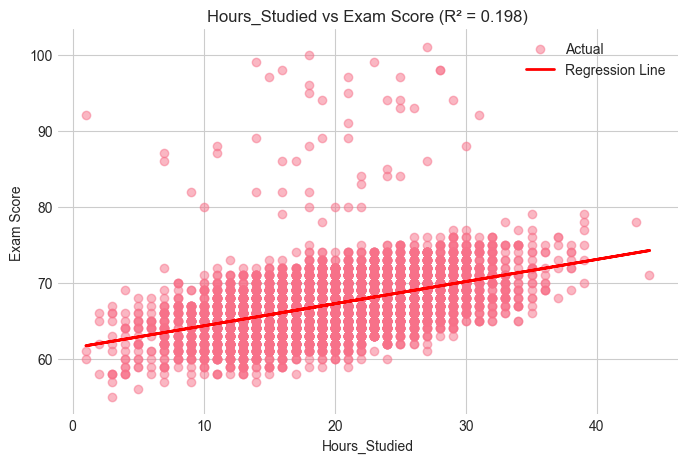


--- Analyzing: Sleep_Hours ---
R² Score: 0.0003
Coefficient: -0.0458
Intercept: 67.5742


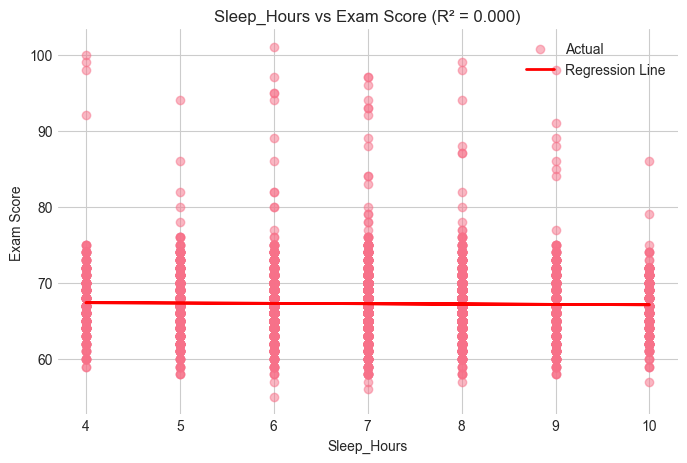


=== COMPARISON RESULTS ===
                R²  Coefficient  Intercept
Hours_Studied 0.20         0.29      61.44
Sleep_Hours   0.00        -0.05      67.57


In [18]:
print("="*60)
print("HYPOTHESIS 1: Individual Impact")
print("="*60)

# Preparing the variables
X_vars = ['Hours_Studied', 'Attendance_Rate', 'Sleep_Hours']
y = df_clean['Exam_Score']

results_h1 = {}

for var in X_vars:
    if var in df_clean.columns:
        print(f"\n--- Analyzing: {var} ---")
        
        # Simple linear regression
        X = df_clean[[var]].values
        y_values = y.values
        
        model = LinearRegression()
        model.fit(X, y_values)
        
        # Predictions and R²
        y_pred = model.predict(X)
        r2 = r2_score(y_values, y_pred)
        
        # Store results
        results_h1[var] = {
            'R²': r2,
            'Coefficient': model.coef_[0],
            'Intercept': model.intercept_
        }
        
        print(f"R² Score: {r2:.4f}")
        print(f"Coefficient: {model.coef_[0]:.4f}")
        print(f"Intercept: {model.intercept_:.4f}")
        
        # Visualization
        plt.figure(figsize=(8, 5))
        plt.scatter(X, y_values, alpha=0.5, label='Actual')
        plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
        plt.xlabel(var)
        plt.ylabel('Exam Score')
        plt.title(f'{var} vs Exam Score (R² = {r2:.3f})')
        plt.legend()
        plt.show()

# Compare R² values
print("\n=== COMPARISON RESULTS ===")
results_df = pd.DataFrame(results_h1).T
print(results_df.sort_values('R²', ascending=False))

- H2: Multiple Regression with Interaction. 

Creating and comparing models


HYPOTHESIS 2: Combined Effects
Columns for model: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Study_Sleep_Group']

--- Model without interaction ---
R²: 0.5374
Adjusted R²: 0.5373

--- Model with interaction ---
R²: 0.5377
Adjusted R²: 0.5374

=== MODEL COMPARISON ===
R² improvement: 0.0002
Adjusted R² improvement: 0.0002

=== INTERACTION TERM SIGNIFICANCE ===
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   46.9968      0.801     58.673      0.000      45.427      48.567
Hours_St

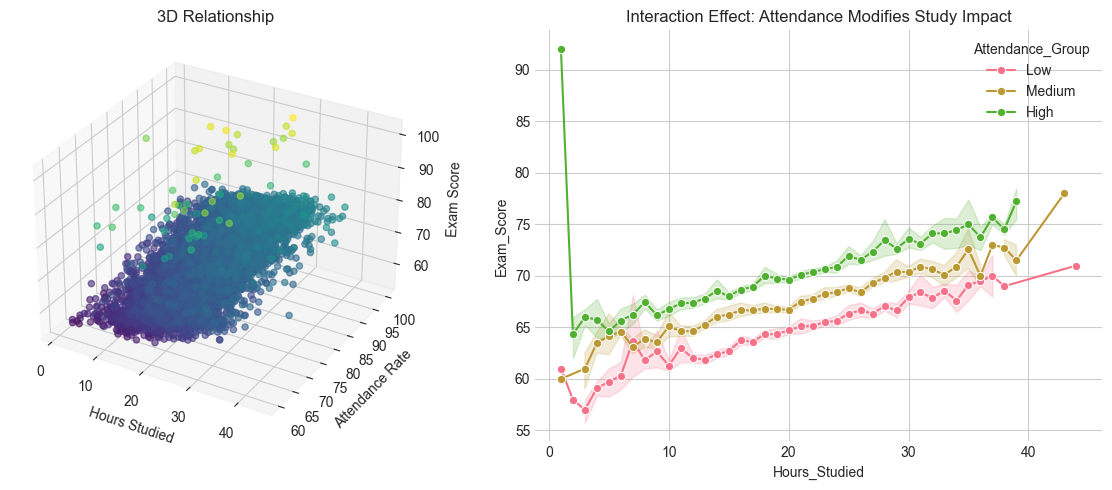

In [25]:
print("\n" + "="*60)
print("HYPOTHESIS 2: Combined Effects")
print("="*60)

# Multiple regression with interaction
from statsmodels.formula.api import ols

# Check column names for formula
print("Columns for model:", df_clean.columns.tolist())

# Model without interaction
model_simple = ols('Exam_Score ~ Hours_Studied + Attendance', data=df_clean).fit()
print("\n--- Model without interaction ---")
print(f"R²: {model_simple.rsquared:.4f}")
print(f"Adjusted R²: {model_simple.rsquared_adj:.4f}")

# Model with interaction
model_interaction = ols('Exam_Score ~ Hours_Studied * Attendance', data=df_clean).fit()
print("\n--- Model with interaction ---")
print(f"R²: {model_interaction.rsquared:.4f}")
print(f"Adjusted R²: {model_interaction.rsquared_adj:.4f}")

# Compare models
print("\n=== MODEL COMPARISON ===")
print(f"R² improvement: {model_interaction.rsquared - model_simple.rsquared:.4f}")
print(f"Adjusted R² improvement: {model_interaction.rsquared_adj - model_simple.rsquared_adj:.4f}")

# Check if interaction term is significant
print("\n=== INTERACTION TERM SIGNIFICANCE ===")
print(model_interaction.summary().tables[1])

# Visualize interaction
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(df_clean['Hours_Studied'], 
           df_clean['Attendance'], 
           df_clean['Exam_Score'], 
           c=df_clean['Exam_Score'], cmap='viridis', alpha=0.6)
ax1.set_xlabel('Hours Studied')
ax1.set_ylabel('Attendance Rate')
ax1.set_zlabel('Exam Score')
ax1.set_title('3D Relationship')

# Interaction plot
ax2 = fig.add_subplot(122)
# Create groups for visualization
df_clean['Attendance_Group'] = pd.qcut(df_clean['Attendance'], q=3, labels=['Low', 'Medium', 'High'])
sns.lineplot(data=df_clean, x='Hours_Studied', y='Exam_Score', 
             hue='Attendance_Group', marker='o')
ax2.set_title('Interaction Effect: Attendance Modifies Study Impact')

plt.tight_layout()
plt.show()

- H3 : Threshold Success



HYPOTHESIS 3: Threshold Success

=== GROUP STATISTICS ===
                   count  mean  std
Study_Sleep_Group                  
High Both           1116 68.74 3.45
High Sleep Only     1294 65.88 3.54
High Study Only     1838 68.76 3.81
Low Both            2130 66.01 3.70


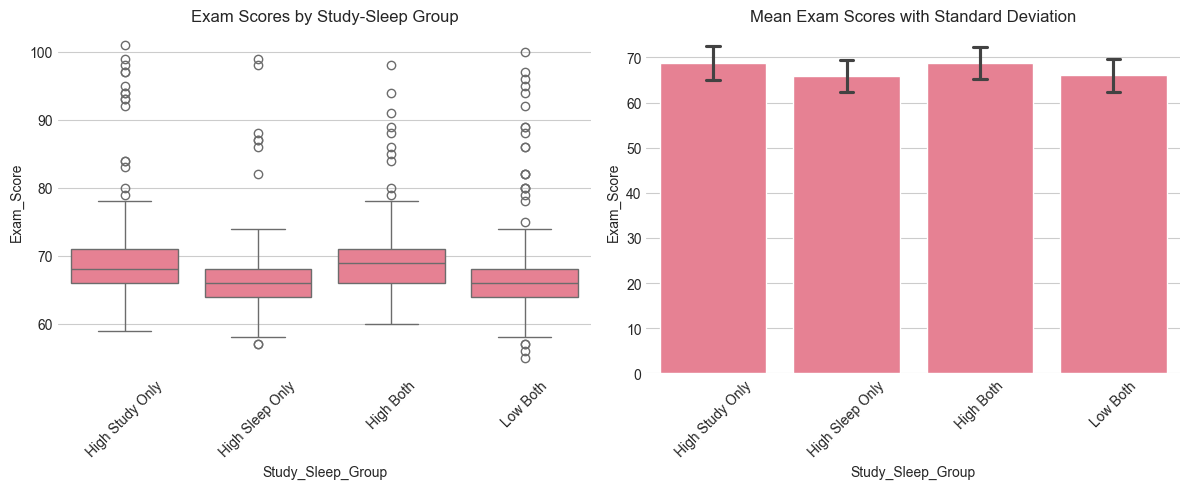


=== ANOVA RESULTS ===
F-statistic: 308.3872
P-value: 0.0000
Conclusion: Significant differences exist between groups (p < 0.05)

=== POST-HOC ANALYSIS (Tukey HSD) ===
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      High Both High Sleep Only  -2.8644    0.0 -3.2485 -2.4803   True
      High Both High Study Only   0.0111 0.9998 -0.3457  0.3679  False
      High Both        Low Both  -2.7385    0.0 -3.0859 -2.3911   True
High Sleep Only High Study Only   2.8755    0.0  2.5343  3.2167   True
High Sleep Only        Low Both   0.1259  0.763 -0.2055  0.4573  False
High Study Only        Low Both  -2.7496    0.0 -3.0489 -2.4503   True
----------------------------------------------------------------------


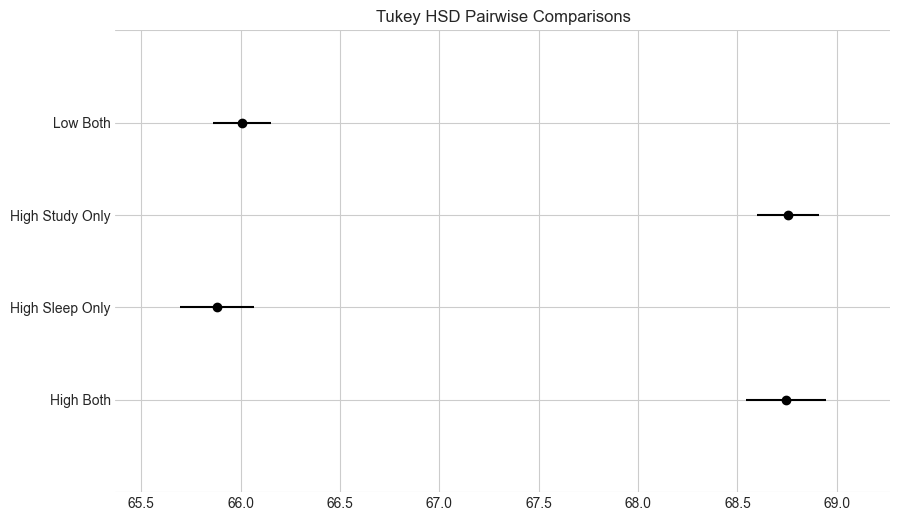

In [26]:
print("\n" + "="*60)
print("HYPOTHESIS 3: Threshold Success")
print("="*60)

# Grouping statistics
group_stats = df_clean.groupby('Study_Sleep_Group')['Exam_Score'].agg(['count', 'mean', 'std'])
print("\n=== GROUP STATISTICS ===")
print(group_stats)

# Visualize groups
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='Study_Sleep_Group', y='Exam_Score')
plt.title('Exam Scores by Study-Sleep Group')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=df_clean, x='Study_Sleep_Group', y='Exam_Score', 
            errorbar='sd', capsize=0.1)
plt.title('Mean Exam Scores with Standard Deviation')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Perform ANOVA
groups = []
for group in df_clean['Study_Sleep_Group'].unique():
    group_data = df_clean[df_clean['Study_Sleep_Group'] == group]['Exam_Score']
    groups.append(group_data)

f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA RESULTS ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Significant differences exist between groups (p < 0.05)")
    
    # Post-hoc test (Tukey HSD)
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    
    tukey = pairwise_tukeyhsd(endog=df_clean['Exam_Score'],
                              groups=df_clean['Study_Sleep_Group'],
                              alpha=0.05)
    print("\n=== POST-HOC ANALYSIS (Tukey HSD) ===")
    print(tukey)
    
    # Visualize pairwise comparisons
    tukey.plot_simultaneous()
    plt.title('Tukey HSD Pairwise Comparisons')
    plt.show()
else:
    print("Conclusion: No significant differences between groups (p >= 0.05)")

- H4: Correlation Matrix Anaylsis

Created correlation matrix by extracting correlation with exam score. 
I have created a heatmap and a bar plot of correlation with exam score.


HYPOTHESIS 4: Variable Comparison
Numerical columns included: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

=== CORRELATIONS WITH EXAM SCORE ===
Exam_Score           1.00
Attendance           0.58
Hours_Studied        0.45
Previous_Scores      0.17
Tutoring_Sessions    0.16
Physical_Activity    0.03
Sleep_Hours         -0.02
Name: Exam_Score, dtype: float64


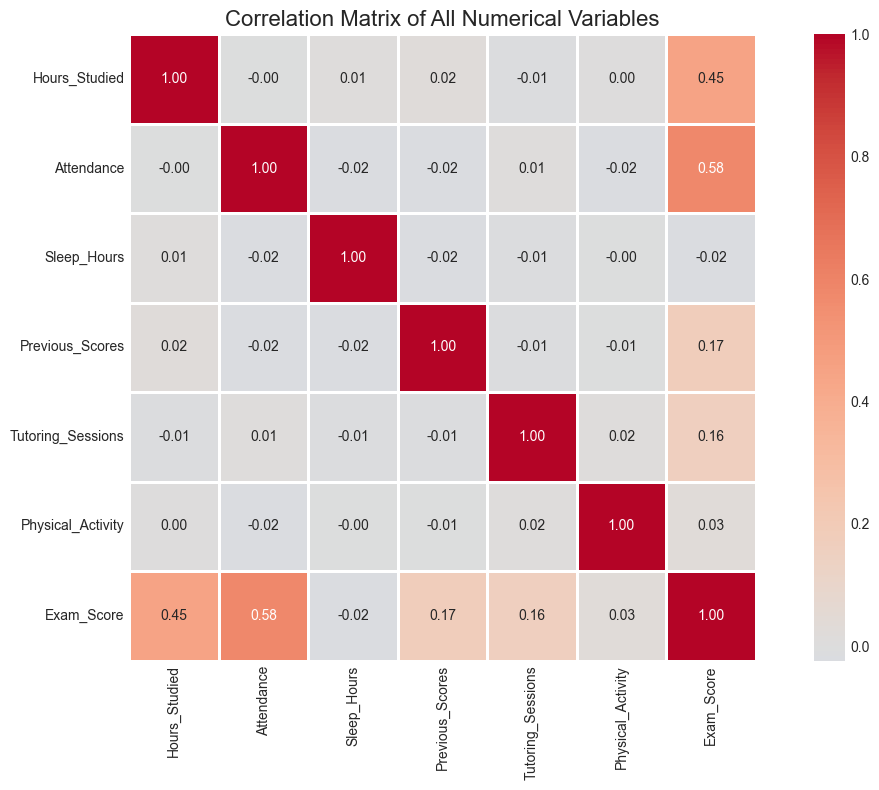

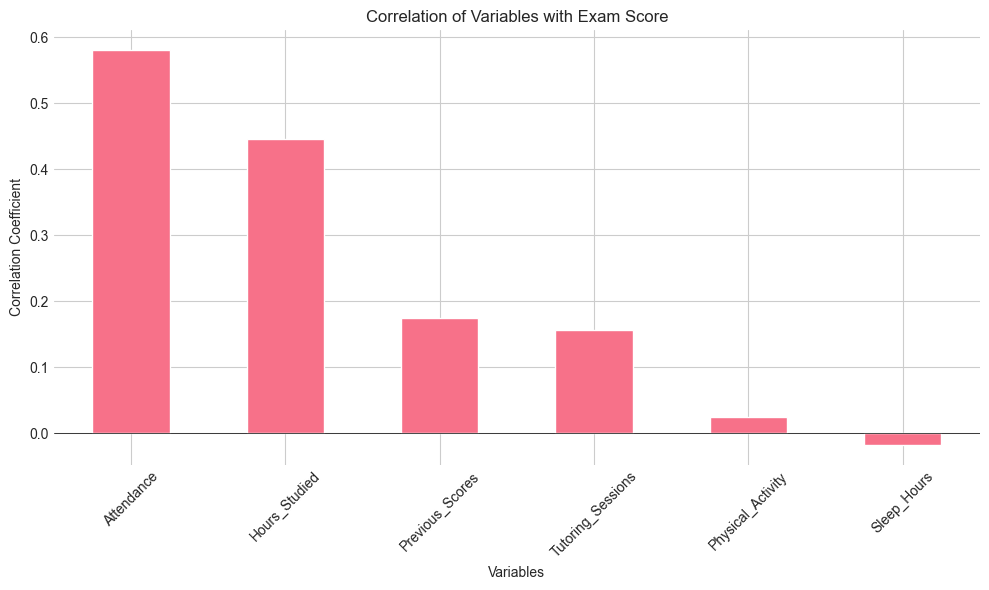


=== HYPOTHESIS 4 TEST ===
Variable with strongest correlation: Attendance
Correlation coefficient: 0.5803
 HYPOTHESIS NOT SUPPORTED: Attendance has stronger correlation than Hours Studied


In [28]:
print("\n" + "="*60)
print("HYPOTHESIS 4: Variable Comparison")
print("="*60)

# Selecting numerical columns for correlation
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns included: {numerical_cols}")

# Calculating correlation matrix
corr_matrix = df_clean[numerical_cols].corr()

# Extracting correlations with Exam Score
exam_correlations = corr_matrix['Exam_Score'].sort_values(ascending=False)
print("\n=== CORRELATIONS WITH EXAM SCORE ===")
print(exam_correlations)

# Creating a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            fmt='.2f')
plt.title('Correlation Matrix of All Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

# Bar plot of correlations with Exam Score
plt.figure(figsize=(10, 6))
exam_correlations.drop('Exam_Score').plot(kind='bar')
plt.title('Correlation of Variables with Exam Score')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Test Hypothesis 4
print("\n=== HYPOTHESIS 4 TEST ===")
top_correlator = exam_correlations.drop('Exam_Score').index[0]
top_correlation = exam_correlations.drop('Exam_Score').iloc[0]

print(f"Variable with strongest correlation: {top_correlator}")
print(f"Correlation coefficient: {top_correlation:.4f}")

if top_correlator == 'Hours_Studied':
    print("HYPOTHESIS SUPPORTED: Hours studied has the strongest correlation!")
else:
    print(f" HYPOTHESIS NOT SUPPORTED: {top_correlator} has stronger correlation than Hours Studied")